# Pretrained SAE Baseline and Steering Experiment


This notebook evaluates a pretrained sparse autoencoder (SAE) on GPT-2 Small. It examines SAE feature activations, tests Feature 974 ("mentions of Paris") on positive and negative examples, and performs a preliminary steering intervention.


In [1]:
import scipy

print(scipy.__version__)
print(scipy.__file__)

1.17.0
c:\Users\shukl\Documents\projects\SAE_faithfulness\SAE_faithfulness\.venv\Lib\site-packages\scipy\__init__.py


In [3]:
from transformer_lens import HookedTransformer
from sae_lens import SAE



In [4]:
model = HookedTransformer.from_pretrained("gpt2-small")

C:\Users\shukl\AppData\Local\Temp\ipykernel_28900\1518716043.py:1: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2-small")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Users\shukl\Documents\projects\SAE_faithfulness\SAE_faithfulness\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shukl\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [5]:
text = "The Eiffel Tower is located in Paris."

tokens = model.to_tokens(text)

print(tokens)
print(model.to_str_tokens(text))

tensor([[50256,   464,   412,   733,   417,  8765,   318,  5140,   287,  6342,
            13]])
['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in', ' Paris', '.']


In [6]:
logits, cache = model.run_with_cache(tokens)

print(logits.shape)

torch.Size([1, 11, 50257])


In [7]:
layer_0_activations = cache["blocks.0.hook_resid_post"]

print(layer_0_activations.shape)

torch.Size([1, 11, 768])


In [8]:
sae = SAE.from_pretrained(
    release="gpt2-small-res-jb",
    sae_id="blocks.8.hook_resid_pre",
    device="cpu"
)

cfg.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

c:\Users\shukl\Documents\projects\SAE_faithfulness\SAE_faithfulness\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shukl\.cache\huggingface\hub\models--jbloom--GPT2-Small-SAEs-Reformatted. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


blocks.8.hook_resid_pre/sae_weights.safe(…): reconstructing file:   0%|          |  0.00B /  151MB            

blocks.8.hook_resid_pre/sae_weights.safe(…): downloading bytes:           |  0.00B            

blocks.8.hook_resid_pre/sparsity.safeten(…): reconstructing file:   0%|          |  0.00B / 98.4kB            

blocks.8.hook_resid_pre/sparsity.safeten(…): downloading bytes:           |  0.00B            

c:\Users\shukl\Documents\projects\SAE_faithfulness\SAE_faithfulness\.venv\Lib\site-packages\sae_lens\saes\sae.py:254: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [10]:
print(sae.cfg)

StandardSAEConfig(d_in=768, d_sae=24576, dtype='float32', device='cpu', apply_b_dec_to_input=True, normalize_activations='none', reshape_activations='none', metadata=SAEMetadata({'sae_lens_version': '6.51.0', 'sae_lens_training_version': None, 'model_name': 'gpt2-small', 'hook_name': 'blocks.8.hook_resid_pre', 'hook_head_index': None, 'dataset_path': 'Skylion007/openwebtext', 'context_size': 128, 'model_from_pretrained_kwargs': {'center_writing_weights': True}, 'neuronpedia_id': 'gpt2-small/8-res-jb', 'prepend_bos': True}))


In [11]:
from sae_lens import HookedSAETransformer

In [12]:
sae_model = HookedSAETransformer.from_pretrained_no_processing(
    "gpt2-small",
    device="cpu"
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [13]:
tokens = sae_model.to_tokens(text)

_, cache = sae_model.run_with_cache(tokens)

layer_8_activations = cache["blocks.8.hook_resid_pre"]

print(layer_8_activations.shape)

torch.Size([1, 11, 768])


In [14]:
feature_activations = sae.encode(layer_8_activations)

print(feature_activations.shape)

torch.Size([1, 11, 24576])


In [15]:
active_features = (feature_activations > 0).sum(dim=-1)

print(active_features)

tensor([[23958,  1446,   762,   136,    93,   292,   418,   550,   697,  1561,
           661]])


In [16]:
str_tokens = sae_model.to_str_tokens(text)

for token, count in zip(str_tokens, active_features[0]):
    print(f"{token!r}: {count.item()} active features")

'<|endoftext|>': 23958 active features
'The': 1446 active features
' E': 762 active features
'iff': 136 active features
'el': 93 active features
' Tower': 292 active features
' is': 418 active features
' located': 550 active features
' in': 697 active features
' Paris': 1561 active features
'.': 661 active features


In [17]:
paris_activations = feature_activations[0, 9]

top_values, top_indices = paris_activations.topk(10)

for feature_id, value in zip(top_indices, top_values):
    print(f"Feature {feature_id.item()}: {value.item():.4f}")

Feature 974: 57.5332
Feature 18593: 20.0779
Feature 7329: 17.8072
Feature 19692: 16.9206
Feature 2281: 14.4675
Feature 12354: 14.0170
Feature 21062: 12.9554
Feature 7583: 12.3691
Feature 23486: 11.9396
Feature 17174: 11.5703


In [18]:
test_text = "I traveled to Paris last summer."

test_tokens = sae_model.to_tokens(test_text)

_, test_cache = sae_model.run_with_cache(test_tokens)

test_layer_8 = test_cache["blocks.8.hook_resid_pre"]

test_features = sae.encode(test_layer_8)

print(sae_model.to_str_tokens(test_text))

['<|endoftext|>', 'I', ' traveled', ' to', ' Paris', ' last', ' summer', '.']


In [19]:
paris_feature_value = test_features[0, 4, 974]

print(paris_feature_value.item())


58.30590057373047


In [20]:
negative_text = "I traveled to London last summer."

negative_tokens = sae_model.to_tokens(negative_text)

_, negative_cache = sae_model.run_with_cache(negative_tokens)

negative_layer_8 = negative_cache["blocks.8.hook_resid_pre"]

negative_features = sae.encode(negative_layer_8)

print(sae_model.to_str_tokens(negative_text))

['<|endoftext|>', 'I', ' traveled', ' to', ' London', ' last', ' summer', '.']


In [21]:
london_feature_value = negative_features[0, 4, 974]

print(london_feature_value.item())

6.6659088134765625


In [25]:
def get_feature_activation(text, feature_id):
    tokens = sae_model.to_tokens(text)

    _, cache = sae_model.run_with_cache(tokens)

    layer_8 = cache["blocks.8.hook_resid_pre"]

    features = sae.encode(layer_8)

    return features[0, 1:, feature_id].max().item()

In [26]:
print(get_feature_activation("I traveled to Paris last summer.", 974))
print(get_feature_activation("I traveled to London last summer.", 974))

58.30590057373047
6.6659088134765625


In [28]:
positive_examples = [
    "I traveled to Paris last summer.",
    "Paris is the capital of France.",
    "She moved to Paris for work.",
    "The conference will be held in Paris.",
    "We visited Paris during our vacation."
]

negative_examples = [
    "I traveled to London last summer.",
    "Berlin is the capital of Germany.",
    "She moved to Chicago for work.",
    "The conference will be held in Tokyo.",
    "We visited Rome during our vacation."
]

print("Positive examples:", len(positive_examples))
print("Negative examples:", len(negative_examples))

Positive examples: 5
Negative examples: 5


In [29]:
positive_scores = []

for sentence in positive_examples:
    score = get_feature_activation(sentence, 974)
    positive_scores.append(score)
    print(f"{sentence} → {score:.2f}")

I traveled to Paris last summer. → 58.31
Paris is the capital of France. → 56.88
She moved to Paris for work. → 57.38
The conference will be held in Paris. → 58.14
We visited Paris during our vacation. → 64.16


In [30]:
negative_scores = []

for sentence in negative_examples:
    score = get_feature_activation(sentence, 974)
    negative_scores.append(score)
    print(f"{sentence} → {score:.2f}")

I traveled to London last summer. → 6.67
Berlin is the capital of Germany. → 9.07
She moved to Chicago for work. → 3.10
The conference will be held in Tokyo. → 8.45
We visited Rome during our vacation. → 7.24


In [31]:
import numpy as np

positive_mean = np.mean(positive_scores)
negative_mean = np.mean(negative_scores)

print(f"Average positive activation: {positive_mean:.2f}")
print(f"Average negative activation: {negative_mean:.2f}")

Average positive activation: 58.97
Average negative activation: 6.91


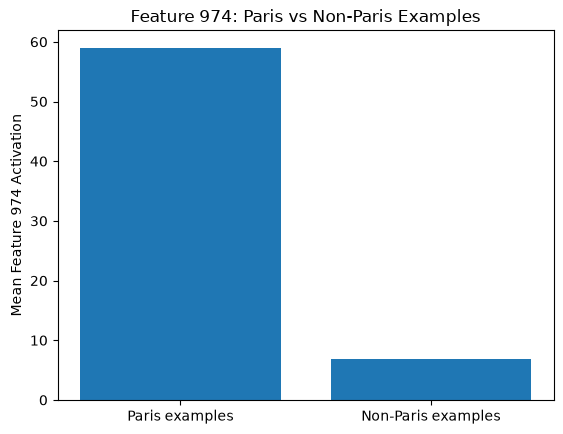

In [38]:
import matplotlib.pyplot as plt

labels = ["Paris examples", "Non-Paris examples"]
means = [positive_mean, negative_mean]

plt.bar(labels, means)

plt.ylabel("Mean Feature 974 Activation")
plt.title("Feature 974: Paris vs Non-Paris Examples")
plt.savefig(
    "../results/figures/feature_974_paris_vs_nonparis.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [34]:
import pandas as pd

In [35]:
results_df = pd.DataFrame({
    "sentence": positive_examples + negative_examples,
    "label": ["Paris"] * len(positive_examples) + ["Non-Paris"] * len(negative_examples),
    "feature_974_activation": positive_scores + negative_scores
})

results_df

,sentence,label,feature_974_activation
0,I traveled to Paris last summer.,Paris,58.305901
1,Paris is the capital of France.,Paris,56.884636
2,She moved to Paris for work.,Paris,57.376465
3,The conference will be held in Paris.,Paris,58.138226
4,We visited Paris during our vacation.,Paris,64.162483
5,I traveled to London last summer.,Non-Paris,6.665909
6,Berlin is the capital of Germany.,Non-Paris,9.069421
7,She moved to Chicago for work.,Non-Paris,3.095961
8,The conference will be held in Tokyo.,Non-Paris,8.453415
9,We visited Rome during our vacation.,Non-Paris,7.244237


In [37]:
results_df.to_csv(
    "../results/tables/feature_974_detection_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [39]:
prompt = "The best place to spend my vacation is"

baseline_output = sae_model.generate(
    prompt,
    max_new_tokens=30,
    temperature=0
)

print(baseline_output)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is in the mountains.

I've been to the mountains a few times and I've never been so excited to see the mountains.

I


In [40]:
feature_id = 974
steering_strength = 20.0

feature_direction = sae.W_dec[feature_id]

def steering_hook(activation, hook):
    activation[:, -1, :] += steering_strength * feature_direction
    return activation

In [41]:
with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output)


  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is at the beach. The beach is a great place to spend a day, but it's also a great place to spend a night. The beach is


In [42]:
steering_strength = 50.0

with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output_50 = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output_50)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is at a hotel.

I love the city, but I also love the people.

I love the people.

I love the


In [43]:
steering_strength = 100.0

with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output_100 = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output_100)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton Hilton


In [44]:
steering_strength = 75.0

with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output_75 = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output_75)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is at a hotel.

The best place to spend my vacation is at a hotel.

The best place to spend my vacation is at a


In [45]:
steering_strength = 30.0

with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output_30 = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output_30)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is at a hotel. I love the hotel, but I also love the food. I love the food, but I also love the food.




In [46]:
steering_strength = 10.0

with sae_model.hooks(
    fwd_hooks=[("blocks.8.hook_resid_pre", steering_hook)]
):
    steered_output_10 = sae_model.generate(
        prompt,
        max_new_tokens=30,
        temperature=0
    )

print(steered_output_10)

  0%|          | 0/30 [00:00<?, ?it/s]

The best place to spend my vacation is in the mountains.

I've been to the mountains a few times and I've never been to a mountain that was as beautiful as this one


In [47]:
steering_results = pd.DataFrame({
    "steering_strength": [0, 10, 20, 30, 50, 75, 100],
    "output": [
        baseline_output,
        steered_output_10,
        steered_output,
        steered_output_30,
        steered_output_50,
        steered_output_75,
        steered_output_100
    ]
})

steering_results

,steering_strength,output
0,0,The best place to spend my vacation is in the ...
1,10,The best place to spend my vacation is in the ...
2,20,The best place to spend my vacation is at the ...
3,30,The best place to spend my vacation is at a ho...
4,50,The best place to spend my vacation is at a ho...
5,75,The best place to spend my vacation is at a ho...
6,100,The best place to spend my vacation is Hilton ...


In [49]:
steering_results.to_csv(
    "../results/tables/feature_974_steering_results.csv",
    index=False
)



In [51]:
steering_results["paris_count"] = (
    steering_results["output"]
    .str.lower()
    .str.count("paris")
)

steering_results[
    ["steering_strength", "mentions_paris", "paris_count"]
]

,steering_strength,mentions_paris,paris_count
0,0,False,0
1,10,False,0
2,20,False,0
3,30,False,0
4,50,False,0
5,75,False,0
6,100,False,0


In [53]:
steering_results.to_csv(
    "../results/tables/feature_974_steering_results.csv",
    index=False
)

